# Summer mean temp for Land (not Coastal) vs Ocean vs Coastal - look into whether the results are different for different latitude zones to see if the initial result for the NH midlatitudes having a lower SummerMeanT for coastal than either ocean or land is explainable

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#from mpl_toolkits.basemap import Basemap

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

# to get rid of runtime warnings when OLS fits hit a divide by zero - handled by setting R2 and p-vals appropriately
import warnings
warnings.filterwarnings('ignore')

In [3]:
# read in data for land and ocean
# input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_LAND_summer_stats.nc'
# ds_land = xr.open_dataset(input_path)

# input_path2 = '../../../Data/ERA5-global/Analysis/New/1961-2023_OCEAN_summer_stats.nc'
# ds_ocean = xr.open_dataset(input_path2)
# merge land and ocean for now
#ds_full = ds_land.merge(ds_ocean)

# read in ALL data for ocean, land, and coastal areas with all flags
input_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_ALL_summer_stats.nc'
ds_full = xr.open_dataset(input_path)

# generate weights for any spatial averages
# (this is a regular grid so we can use cos(latitude))
weights = np.cos(np.deg2rad(ds_full.lat))
weights.name = "weights"

ds_full


<xarray.Dataset> Size: 5GB
Dimensions:       (lat: 721, lon: 1440, time: 63)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time          (time) datetime64[ns] 504B 1961-01-01 ... 2023-01-01
Data variables:
    SummerStart   (time, lat, lon) float64 523MB ...
    SummerEnd     (time, lat, lon) float64 523MB ...
    SummerTmax    (time, lat, lon) float64 523MB ...
    SummerHeat    (time, lat, lon) float64 523MB ...
    SummerLength  (time, lat, lon) float64 523MB ...
    SummerRMSE    (time, lat, lon) float64 523MB ...
    SummerR2      (time, lat, lon) float64 523MB ...
    SummerMeanT   (time, lat, lon) float64 523MB ...
    SummerMeanHS  (time, lat, lon) float64 523MB ...
    lsm           (time, lat, lon) float64 523MB ...
    Coastal       (time, lat, lon) bool 65MB ...

## Plots of SummerMeanT in NH latitude chunks

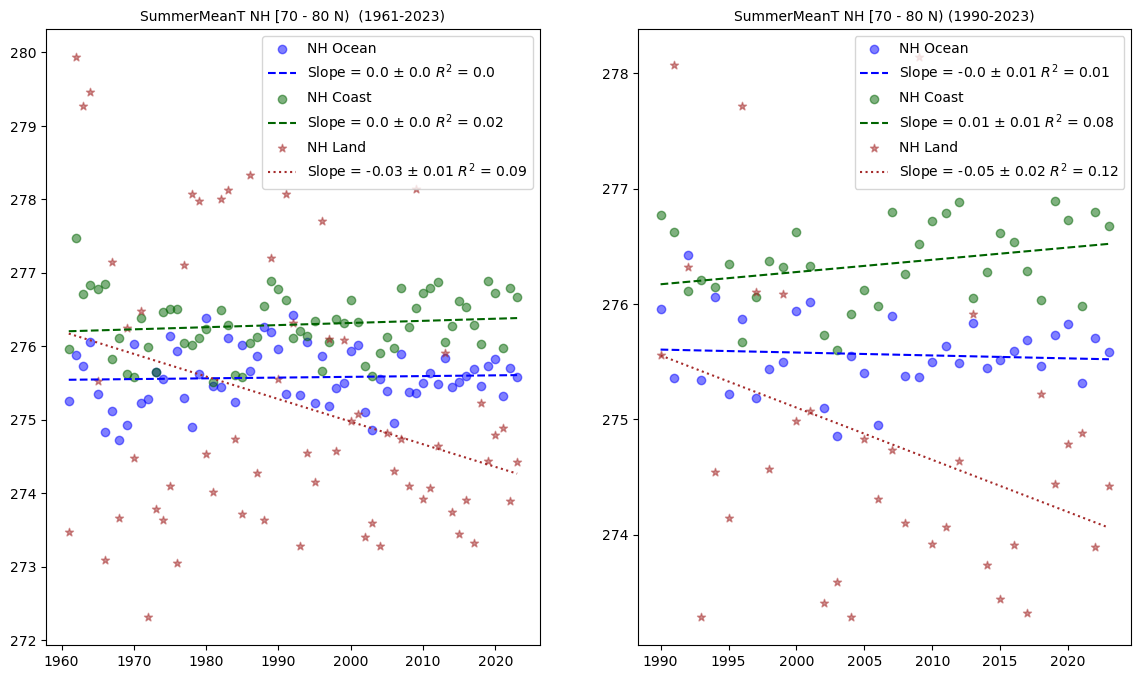

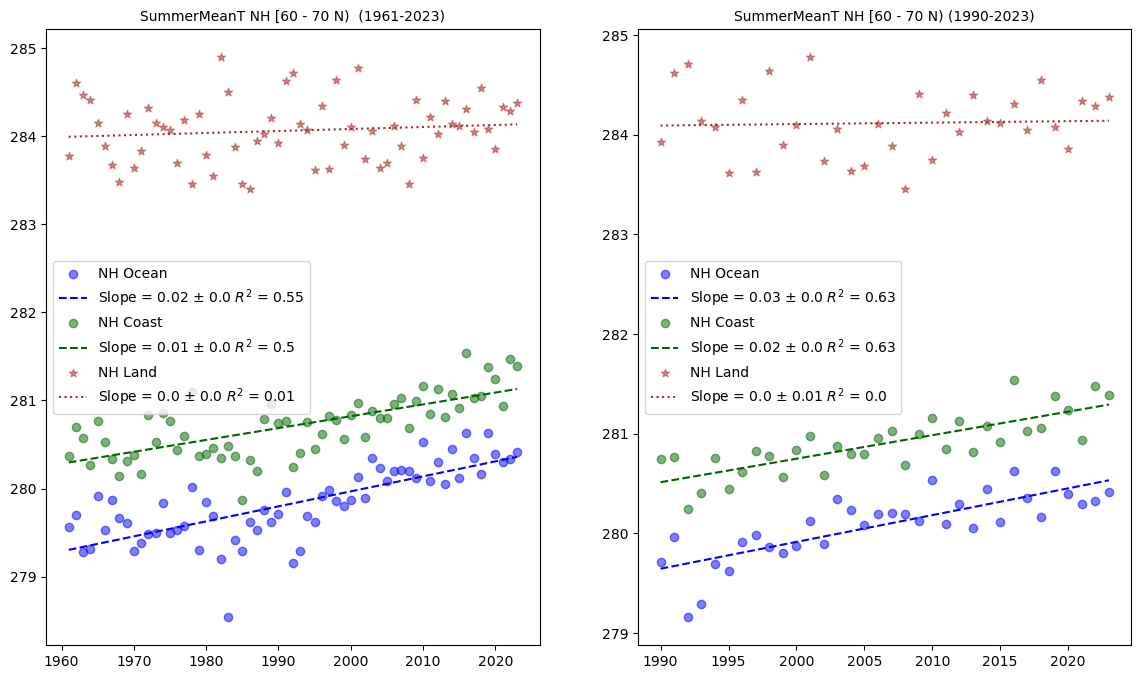

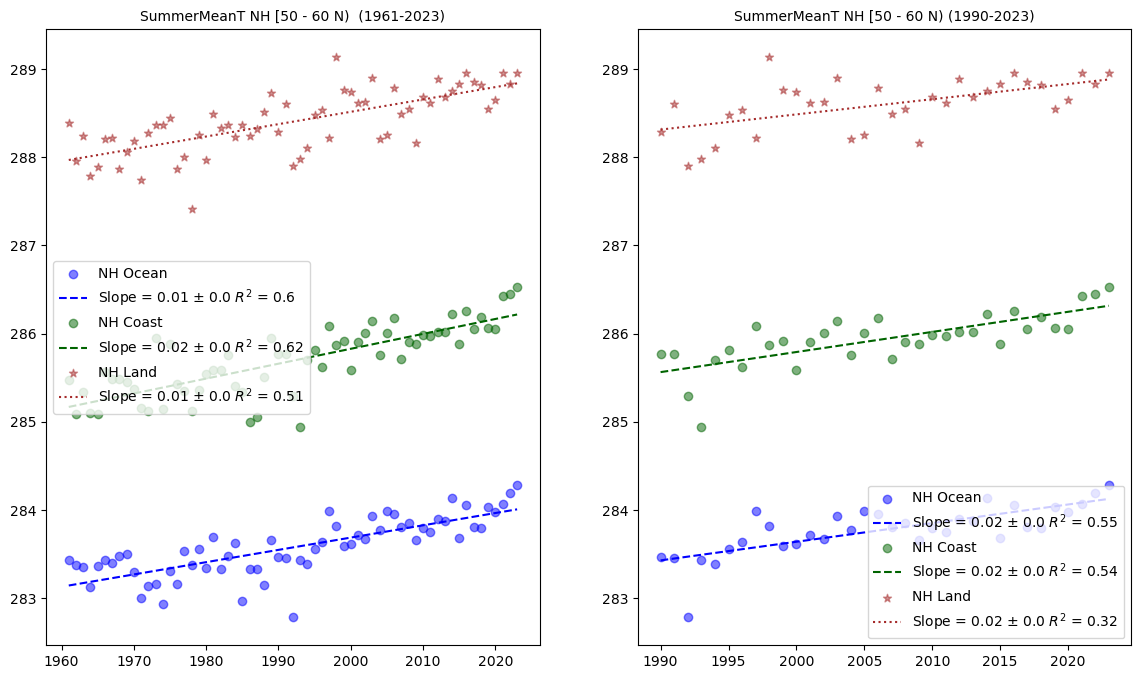

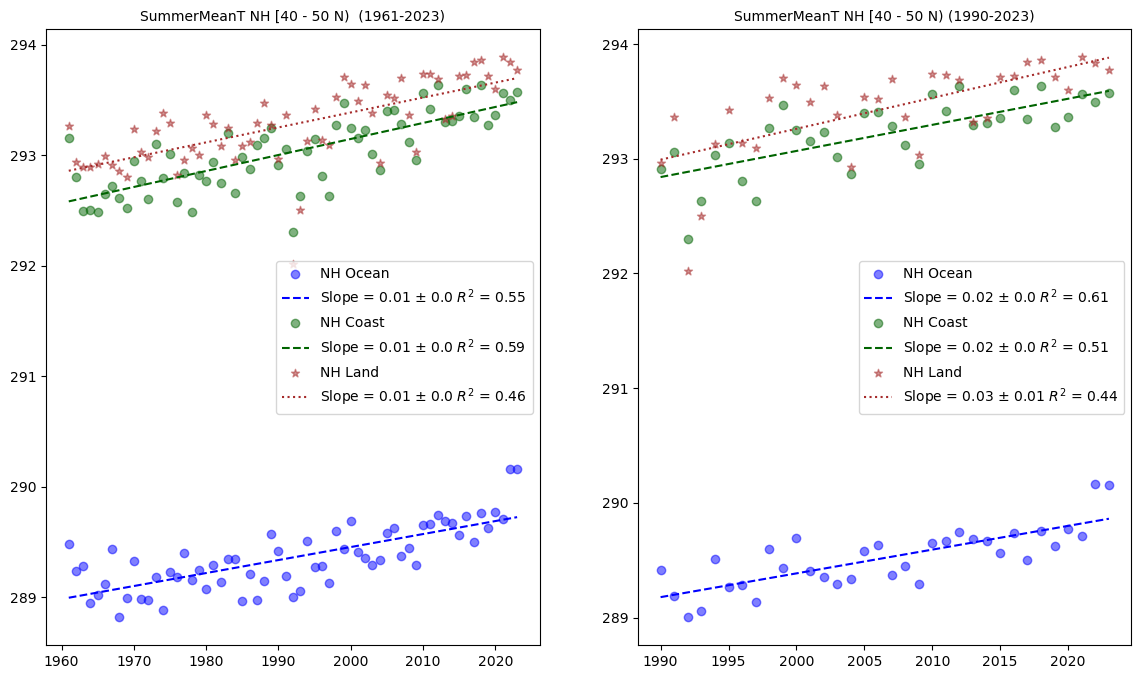

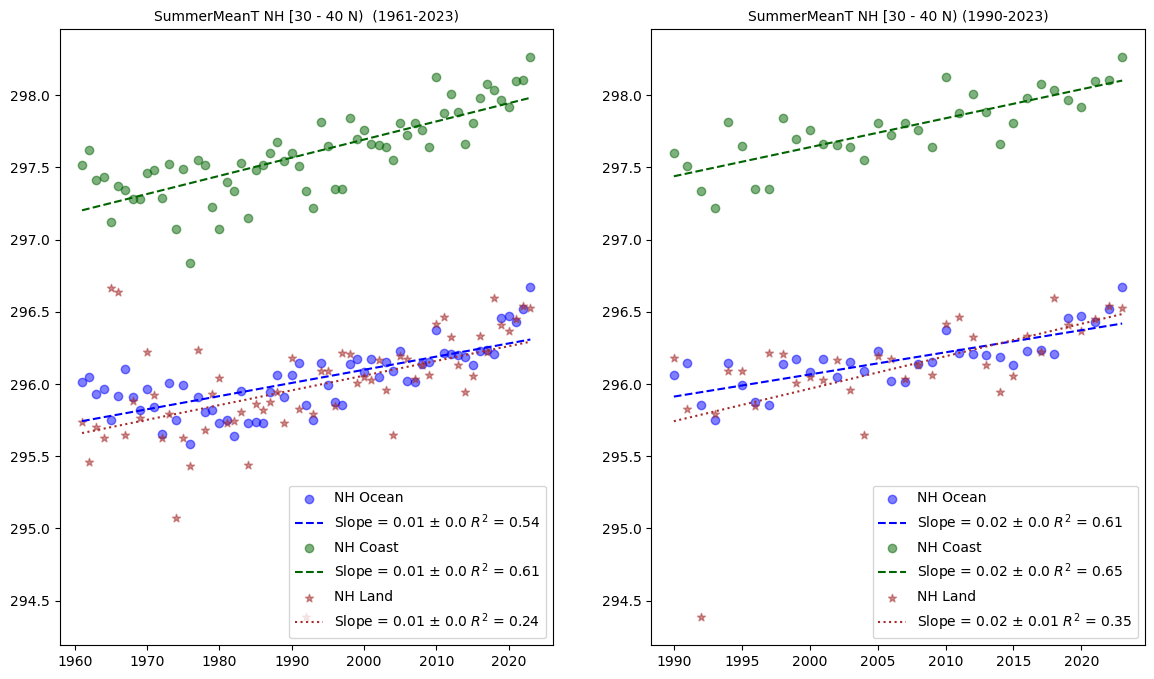

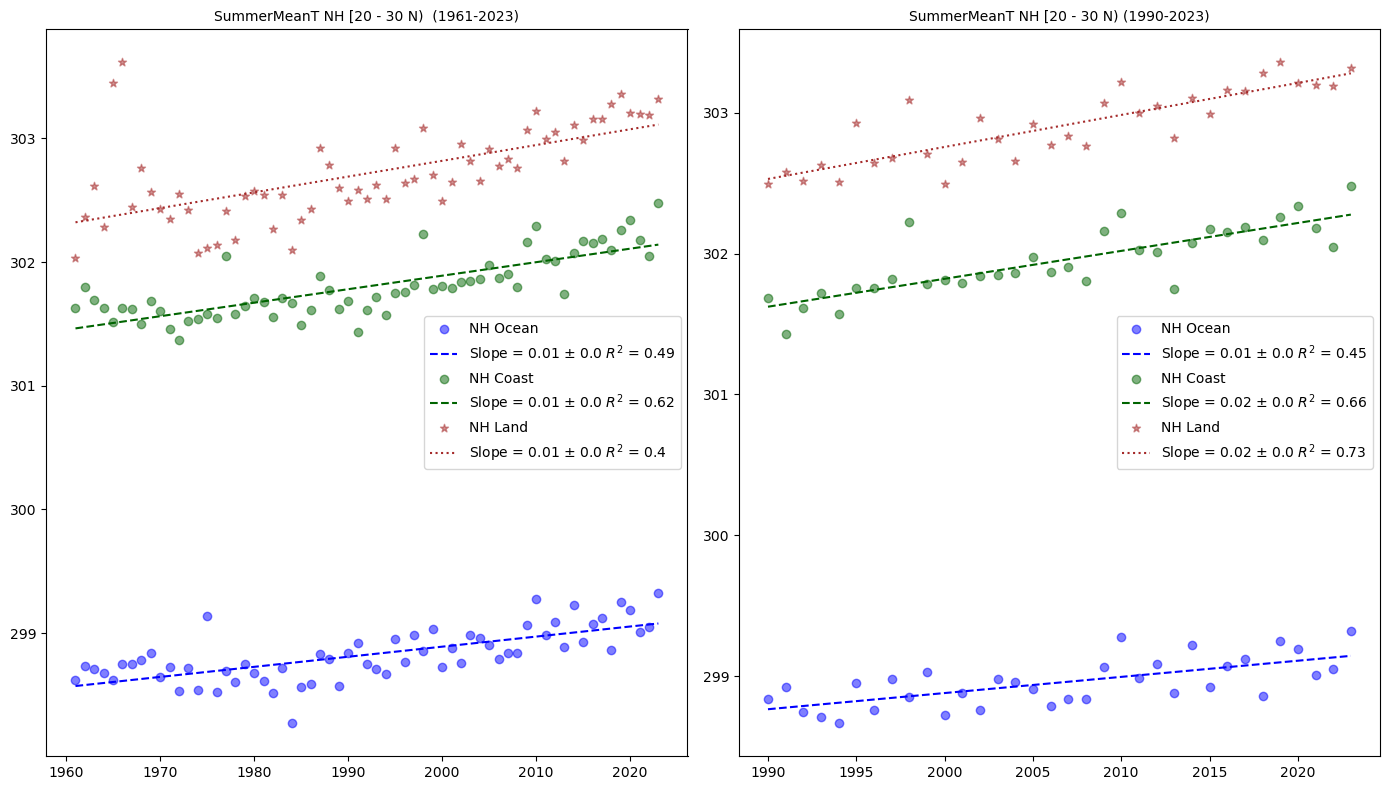

CPU times: user 1min 12s, sys: 47.1 s, total: 1min 59s
Wall time: 2min 2s


In [43]:
%%time

# takes 2.5 min


# 10 degree latitude buckets
lat_bins = [70,60,50,40,30,20]



# loop through all plot variables
for i,v in enumerate(lat_bins):

    # datasets of weighted averages for the midlatitudes for these lat buckets
    # for now, removing grid cells from averages where the mean summer temp was 0 K meaning no summer
    nh_land_full = ds_full.where((ds_full.lsm > 0.5) & (ds_full.SummerMeanT > 0) & (ds_full.Coastal == False) &
                                 ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
    
    nh_coast_full = ds_full.where((ds_full.Coastal) & (ds_full.SummerMeanT > 0) &
                                  ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    nh_ocean_full = ds_full.where((ds_full.lsm <= 0.5) & (ds_full.SummerMeanT > 0) &
                              ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    nh_ocean_an = ds_full.sel(time=slice('1990','2023')).where((ds_full.lsm <= 0.5) & (ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
        
    nh_land_an = ds_full.sel(time=slice('1990','2023')).where((ds_full.lsm > 0.5) & (ds_full.SummerMeanT > 0) & (ds_full.Coastal == False) &
                                                          ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    nh_coast_an = ds_full.sel(time=slice('1990','2023')).where((ds_full.Coastal) & (ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])


    
    # create blank fig
    fig = plt.figure(figsize = (14,8))
    
    # Full Time Period NH
    ax1 = fig.add_subplot(1,2,1)

    # linear fits for slope
    x_land = nh_land_full.time.dt.year.values
    y_land = nh_land_full.SummerMeanT.values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_coast = nh_coast_full.time.dt.year.values
    y_coast = nh_coast_full.SummerMeanT.values
    coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
    poly_coast = np.poly1d(coefs_coast)
    slope_coast = np.round(coefs_coast[0],2)
    slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_coast)
    ss_total = np.sum((y_coast - ymean)**2)
    ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_coast = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = nh_ocean_full.time.dt.year.values
    y_ocean = nh_ocean_full.SummerMeanT.values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax1.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", alpha=0.5)
    ax1.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
    ax1.scatter(x_coast, y_coast, label="NH Coast", c="darkgreen", alpha=0.5)
    ax1.plot(x_coast, poly_coast(x_coast), linestyle="dashed", color='darkgreen', 
         label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
    ax1.scatter(x_land, y_land, label="NH Land", marker='*', facecolors='brown', edgecolors='brown', alpha=0.5)
    ax1.plot(x_land, poly_land(x_land), linestyle="dotted", color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax1.set_title("SummerMeanT NH [" + str(v) +" - " + str(v+10) + " N)  (1961-2023)", fontsize = 10)
    ax1.legend(loc='best')



    # Analysis time period NH
    ax2 = fig.add_subplot(1,2,2)

    # linear fits for slope
    x_land = nh_land_an.time.dt.year.values
    y_land = nh_land_an.SummerMeanT.values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_coast = nh_coast_an.time.dt.year.values
    y_coast = nh_coast_an.SummerMeanT.values
    coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
    poly_coast = np.poly1d(coefs_coast)
    slope_coast = np.round(coefs_coast[0],2)
    slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_coast)
    ss_total = np.sum((y_coast - ymean)**2)
    ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_coast = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = nh_ocean_an.time.dt.year.values
    y_ocean = nh_ocean_an.SummerMeanT.values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax2.scatter(x_ocean, y_ocean, label="NH Ocean", c="blue", alpha=0.5)
    ax2.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
    ax2.scatter(x_coast, y_coast, label="NH Coast", c="darkgreen", alpha=0.5)
    ax2.plot(x_coast, poly_coast(x_coast), linestyle="dashed", color='darkgreen', 
         label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
    ax2.scatter(x_land, y_land, label="NH Land", marker='*', facecolors='brown', edgecolors='brown', alpha=0.5)
    ax2.plot(x_land, poly_land(x_land), linestyle="dotted", color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax2.set_title("SummerMeanT NH [" + str(v) +" - " + str(v+10) + " N) (1990-2023)", fontsize = 10)
    ax2.legend(loc='best')


plt.tight_layout()
plt.show()

# Determine linear trends in Summer Mean HS per grid cell and write them out

In [32]:
%%time

# limit data to SummerMeanHS and only include valid summer mean temp values (0 is equiv to nan)
ds_full_meanHS = ds_full.SummerMeanHS.where(ds_full.SummerMeanT > 0)

# takes 8.5 min for 63 years

# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = ds_full_meanHS.lat.values[:num_lat]
loop_lons = ds_full_meanHS.lon.values[:num_lon]


# empty data arrays for summer stats
meanHS_slope = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])
meanHS_pval = xr.DataArray(np.zeros((num_lat,num_lon)), 
                           coords=[loop_lats, loop_lons], 
                           dims=['lat','lon'])
meanHS_r2 = xr.DataArray(np.zeros((num_lat,num_lon)), 
                           coords=[loop_lats, loop_lons], 
                           dims=['lat','lon'])

# add attributes
meanHS_slope.attrs["long_name"] = "Slope of linear fit of summer meanHS over time"
meanHS_slope.attrs["units"] = "Days/year"

meanHS_pval.attrs["long_name"] = "p-value of linear fit"
meanHS_pval.attrs["units"] = "None"

meanHS_r2.attrs["long_name"] = "R^2 (coeff of determination) for linear fit"
meanHS_r2.attrs["units"] = "None"


# loop through all of the lat,lon of interest
for input_lat in loop_lats:
    for input_lon in loop_lons:

        # create x & y values for linear fit
        x = ds_full_meanHS.time.dt.year.values
        y = ds_full_meanHS.sel(lat=input_lat, lon=input_lon).values

        # OLS
        x = sm.add_constant(x)
        model = sm.OLS(y, x).fit()
        #print(model.summary())
        
        # load up data arrays with fit values
        meanHS_slope.loc[input_lat, input_lon] = model.params[1]

        # deal with few grid cells that return nan for Pvalue and R2 on fit
        if np.isnan(model.pvalues[1]):
            meanHS_pval.loc[input_lat, input_lon] = 1
            meanHS_r2.loc[input_lat, input_lon] = 0
        else:
            # otherwise fit pvalue and r2 are OK
            meanHS_pval.loc[input_lat, input_lon] = model.pvalues[1]
            meanHS_r2.loc[input_lat, input_lon] = model.rsquared
        
# results dataset
results_ds = xr.Dataset(data_vars={'MeanHSSlope':meanHS_slope,
                           'MeanHSPvalue':meanHS_pval,
                           'MeanHSR2':meanHS_r2})

# see results
results_ds

CPU times: user 8min 37s, sys: 4.78 s, total: 8min 42s
Wall time: 8min 42s


<xarray.Dataset> Size: 25MB
Dimensions:       (lat: 721, lon: 1440)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    MeanHSSlope   (lat, lon) float64 8MB nan nan nan nan nan ... nan nan nan nan
    MeanHSPvalue  (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    MeanHSR2      (lat, lon) float64 8MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

## Apply FDR

In [33]:
# use func from scipi.stats
pval_fdr_cor = stats.false_discovery_control(results_ds.MeanHSPvalue.values)

# add as variable to dataset
results_ds['MeanHSPvalFDR'] = (['lat','lon'], pval_fdr_cor)

results_ds

<xarray.Dataset> Size: 33MB
Dimensions:        (lat: 721, lon: 1440)
Coordinates:
  * lat            (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon            (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    MeanHSSlope    (lat, lon) float64 8MB nan nan nan nan ... nan nan nan nan
    MeanHSPvalue   (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    MeanHSR2       (lat, lon) float64 8MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    MeanHSPvalFDR  (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0

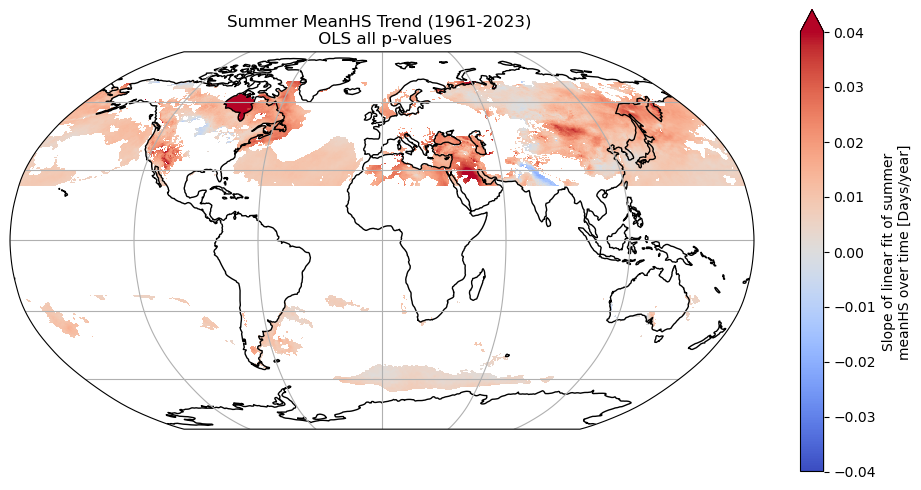

In [42]:

# Global summer meanHS trend
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

results_ds.MeanHSSlope.where((((ds_full_meanHS.lat >= 23.5) & (ds_full_meanHS.lat <= 70)) | 
                              ((ds_full_meanHS.lat <= -23.5) & (ds_full_meanHS.lat >= -70)))).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-0.04,
    vmax=0.04,
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Summer MeanHS Trend (1961-2023) \n OLS all p-values")#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

## Plot using FDR correction on p-values, now with a threshold of 0.1


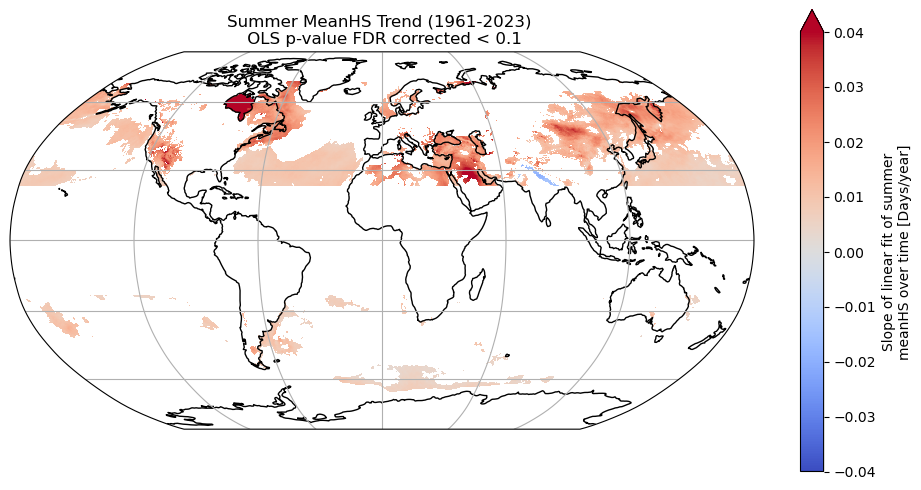

In [41]:

# Global summer meanHS trend
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

results_ds.MeanHSSlope.where((results_ds.MeanHSPvalFDR <= 0.1) & (((ds_full_meanHS.lat >= 23.5) & (ds_full_meanHS.lat <= 70)) | 
                              ((ds_full_meanHS.lat <= -23.5) & (ds_full_meanHS.lat >= -70)))).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-0.04,
    vmax=0.04, 
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Summer MeanHS Trend (1961-2023) \n OLS p-value FDR corrected < 0.1")#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

## Now do same analysis for Summer MeanHS trends over analysis period: 1990-2023

In [36]:
# restrict to 1990-2023
ds_meanHS_analysis = ds_full_meanHS.sel(time=slice('1990','2023'))
ds_meanHS_analysis
                                    

<xarray.DataArray 'SummerMeanHS' (time: 34, lat: 721, lon: 1440)> Size: 282MB
array([[[8.852005  , 8.852005  , 8.852005  , ..., 8.852005  ,
         8.852005  , 8.852005  ],
        [8.8136461 , 8.81345113, 8.81302728, ..., 8.81221008,
         8.81241862, 8.81283061],
        [8.66584455, 8.6593312 , 8.65567124, ..., 8.65696403,
         8.63339742, 8.67255326],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
...
        [2.25912999, 2.26100638, 2.26032453, ..., 2.25455061,
         2.25518363, 2.25709316],
        [2.21973936, 2.22059484, 2.22132726, ..., 2.21720148,
         2.21808747, 2.21903549],
        [2.26947632, 2.26947632, 2.26947632, ..., 2.26947632,
         2.26947632, 2.26947632]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [2.20535996, 2.21859567, 2.21785801, ..., 2.20091517,
         2.20157937, 2.20332067],
        [2.19834949, 2.19920497, 2.20000039, ..., 2.19587461,
         2.19676061, 2.19764562],
        [2.1651001 , 2.1651001 , 2.1651001 , ..., 2.1651001 ,
         2.1651001 , 2.1651001 ]]])
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time     (time) datetime64[ns] 272B 1990-01-01 1991-01-01 ... 2023-01-01
Attributes:
    long_name:  Mean HS temperature during the summer period
    units:      Degrees [K]

### Linear trends for each grid cell 1990-2023

In [37]:
%%time

# takes 10 min for 63 years

# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = ds_meanHS_analysis.lat.values[:num_lat]
loop_lons = ds_meanHS_analysis.lon.values[:num_lon]

# empty data arrays for summer stats
meanHS_slope = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])
meanHS_pval = xr.DataArray(np.zeros((num_lat,num_lon)), 
                           coords=[loop_lats, loop_lons], 
                           dims=['lat','lon'])
meanHS_r2 = xr.DataArray(np.zeros((num_lat,num_lon)), 
                           coords=[loop_lats, loop_lons], 
                           dims=['lat','lon'])

# add attributes
meanHS_slope.attrs["long_name"] = "Slope of linear fit of summer meanHS over time"
meanHS_slope.attrs["units"] = "Days/year"

meanHS_pval.attrs["long_name"] = "p-value of linear fit"
meanHS_pval.attrs["units"] = "None"

meanHS_r2.attrs["long_name"] = "R^2 (coeff of determination) for linear fit"
meanHS_r2.attrs["units"] = "None"


# loop through all of the lat,lon of interest
for input_lat in loop_lats:
    for input_lon in loop_lons:

        # create x & y values for linear fit
        x = ds_meanHS_analysis.time.dt.year.values
        y = ds_meanHS_analysis.sel(lat=input_lat, lon=input_lon).values

        # OLS
        x = sm.add_constant(x)
        model = sm.OLS(y, x).fit()
        #print(model.summary())
        
        # load up data arrays with fit values
        meanHS_slope.loc[input_lat, input_lon] = model.params[1]

        # deal with few grid cells that return nan for Pvalue and R2 on fit
        if (np.isnan(model.pvalues[1]) | np.isnan(model.rsquared)):
            #print("This one has nans: "+str(input_lat)+","+str(input_lon))
            meanHS_pval.loc[input_lat, input_lon] = 1.0
            meanHS_r2.loc[input_lat, input_lon] = 0.0
        else:
            # otherwise fit pvalue and r2 are OK
            meanHS_pval.loc[input_lat, input_lon] = model.pvalues[1]
            meanHS_r2.loc[input_lat, input_lon] = model.rsquared
        
# results dataset
results_ds_an = xr.Dataset(data_vars={'MeanHSSlope':meanHS_slope,
                           'MeanHSPvalue':meanHS_pval,
                           'MeanHSR2':meanHS_r2})

# see results
results_ds_an

CPU times: user 9min 6s, sys: 8.22 s, total: 9min 14s
Wall time: 9min 15s


<xarray.Dataset> Size: 25MB
Dimensions:       (lat: 721, lon: 1440)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    MeanHSSlope   (lat, lon) float64 8MB nan nan nan nan nan ... nan nan nan nan
    MeanHSPvalue  (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    MeanHSR2      (lat, lon) float64 8MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [38]:
# diagnose scalar divide warning on some cells - this should be zero so we can do FDR correction
np.count_nonzero(np.isnan(results_ds_an.MeanHSPvalue.values))

0

### Apply FDR correction to p-values

In [39]:
# use func from scipi.stats
pval_fdr_cor = stats.false_discovery_control(results_ds_an.MeanHSPvalue.values)

# add as variable to dataset
results_ds_an['MeanHSPvalFDR'] = (['lat','lon'], pval_fdr_cor)

results_ds_an

<xarray.Dataset> Size: 33MB
Dimensions:        (lat: 721, lon: 1440)
Coordinates:
  * lat            (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon            (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    MeanHSSlope    (lat, lon) float64 8MB nan nan nan nan ... nan nan nan nan
    MeanHSPvalue   (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    MeanHSR2       (lat, lon) float64 8MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    MeanHSPvalFDR  (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0

In [40]:
# write those results out for later use
output_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_MeanHSTrends.nc'
results_ds.to_netcdf(output_path)

output_path2 = '../../../Data/ERA5-global/Analysis/New/1990-2023_MeanHSTrends.nc'
results_ds_an.to_netcdf(output_path2)

## What are the average latitudes for Inland, Coastal, and Ocean in the NH?

In [5]:
# latitude & longitude ranges for NH and SH midlatitudes so they will be easy to adjust
nh_min = 23.5
nh_max = 70


# datasets of weighted averages for the midlatitudes
# for now, removing grid cells from averages where the mean summer temp was 0 K meaning no summer
# quick counts suggest this loses 1.5 - 2% of grid cells across the 63 years
nh_land_mean_lat = ds_full.SummerMeanT.lat.where((ds_full.lsm > 0.5) & (ds_full.SummerMeanT > 0) & (ds_full.Coastal == False) &
                             ((ds_full.lat >= nh_min) & (ds_full.lat <= nh_max))).sel(time='2023').mean()

nh_coast_mean_lat = ds_full.SummerMeanT.lat.where((ds_full.Coastal) & (ds_full.SummerMeanT > 0) &
                              ((ds_full.lat >= nh_min) & (ds_full.lat <= nh_max))).sel(time='2023').mean()

nh_ocean_mean_lat = ds_full.SummerMeanT.lat.where((ds_full.lsm <= 0.5) & (ds_full.SummerMeanT > 0) & 
                             ((ds_full.lat >= nh_min) & (ds_full.lat <= nh_max))).sel(time='2023').mean()

print("Mean lat for Inland: "+str(nh_land_mean_lat))
print("Mean lat for Coastal: "+str(nh_coast_mean_lat))
print("Mean lat for Ocean: "+str(nh_ocean_mean_lat))

Mean lat for Inland: <xarray.DataArray 'lat' ()> Size: 8B
array(49.45327469)
Mean lat for Coastal: <xarray.DataArray 'lat' ()> Size: 8B
array(50.96078641)
Mean lat for Ocean: <xarray.DataArray 'lat' ()> Size: 8B
array(43.73284943)


## Violin Plots of Lat Values for NH

In [6]:
# pick a year
nh_land_lat = ds_full.SummerMeanT.sel(time='2023').where((ds_full.lsm > 0.5) & (ds_full.SummerMeanT > 0) & (ds_full.Coastal == False) &
                             ((ds_full.lat >= nh_min) & (ds_full.lat <= nh_max)), drop=True)

nh_coast_lat = ds_full.SummerMeanT.sel(time='2023').where((ds_full.Coastal == True) & (ds_full.SummerMeanT > 0) &
                              ((ds_full.lat >= nh_min) & (ds_full.lat <= nh_max)), drop=True)

nh_ocean_lat = ds_full.SummerMeanT.sel(time='2023').where((ds_full.lsm <= 0.5) & (ds_full.SummerMeanT > 0) & 
                             ((ds_full.lat >= nh_min) & (ds_full.lat <= nh_max)), drop=True)



In [7]:
np.count_nonzero(~np.isnan(nh_coast_lat)), np.count_nonzero(~np.isnan(nh_land_lat)), np.count_nonzero(~np.isnan(nh_ocean_lat))

(7032, 137784, 127401)

### Seems I have to loop through each to build the list of latitude values

In [8]:
%%time

# 90 sec

# build list of lat values for each subset
# each needs its own loop since not all lon values are represented in each dataset
land_lats=[]
for i in nh_land_lat.lat.values:
    for j in nh_land_lat.lon.values:
        if(~np.isnan(nh_land_lat.sel(lat=i, lon=j))):
            land_lats.append(i)

coast_lats=[]
for i in nh_coast_lat.lat.values:
    for j in nh_coast_lat.lon.values:
        if(~np.isnan(nh_coast_lat.sel(lat=i, lon=j))):
            coast_lats.append(i)

ocean_lats=[]
for i in nh_ocean_lat.lat.values:
    for j in nh_ocean_lat.lon.values:
        if(~np.isnan(nh_ocean_lat.sel(lat=i, lon=j))):
            ocean_lats.append(i)



CPU times: user 1min 24s, sys: 851 ms, total: 1min 25s
Wall time: 1min 25s


### Violin plots

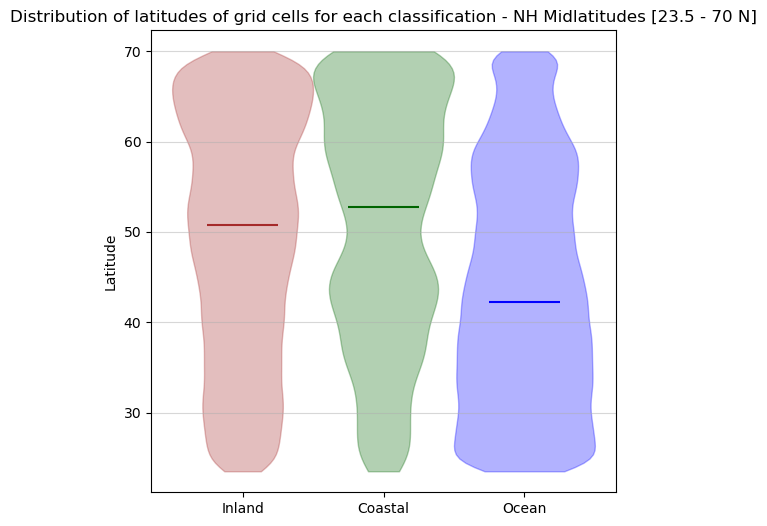

In [9]:
data = [land_lats, coast_lats, ocean_lats]
colors = ['brown', 'darkgreen', 'blue']
labels = ['Inland', 'Coastal', 'Ocean']

fig, ax = plt.subplots(1, 1, figsize=(6,6))
plots = ax.violinplot(data, vert=True, showmedians=True, showextrema=False, widths=1)
for i, (pc,color) in enumerate(zip(plots['bodies'], colors)):
        pc.set_facecolor(color)
        pc.set_edgecolor(color)

# Set the color of the median lines
plots['cmedians'].set_colors(colors)

ax.set_ylabel("Latitude")
ax.set_xticks(np.arange(1,len(labels)+1),labels=labels)
#ax.set_xticks(np.arange(140,300,10))
plt.grid(axis="y", which='both', alpha=0.5)
plt.title("Distribution of latitudes of grid cells for each classification - NH Midlatitudes [23.5 - 70 N]")
plt.show()

## Violin Plots of Lat Values for SH

In [10]:
# SH Midlatitudes
sh_max = -23.5
sh_min = -70

sh_land_lat = ds_full.SummerMeanT.sel(time='2023').where((ds_full.lsm > 0.5) & (ds_full.SummerMeanT > 0) & (ds_full.Coastal == False) &
                             ((ds_full.lat >= sh_min) & (ds_full.lat <= sh_max)), drop=True)

sh_coast_lat = ds_full.SummerMeanT.sel(time='2023').where((ds_full.Coastal == True) & (ds_full.SummerMeanT > 0) &
                              ((ds_full.lat >= sh_min) & (ds_full.lat <= sh_max)), drop=True)

sh_ocean_lat = ds_full.SummerMeanT.sel(time='2023').where((ds_full.lsm <= 0.5) & (ds_full.SummerMeanT > 0) & 
                             ((ds_full.lat >= sh_min) & (ds_full.lat <= sh_max)), drop=True)



In [11]:
np.count_nonzero(~np.isnan(sh_coast_lat)), np.count_nonzero(~np.isnan(sh_land_lat)), np.count_nonzero(~np.isnan(sh_ocean_lat))

(1665, 17687, 219848)

### Seems I have to loop through each to build the list of latitude values

In [12]:
%%time

# build list of lat values for each subset
# each needs its own loop since not all lon values are represented in each dataset
land_lats=[]
for i in sh_land_lat.lat.values:
    for j in sh_land_lat.lon.values:
        if(~np.isnan(sh_land_lat.sel(lat=i, lon=j))):
            land_lats.append(i)

coast_lats=[]
for i in sh_coast_lat.lat.values:
    for j in sh_coast_lat.lon.values:
        if(~np.isnan(sh_coast_lat.sel(lat=i, lon=j))):
            coast_lats.append(i)

ocean_lats=[]
for i in sh_ocean_lat.lat.values:
    for j in sh_ocean_lat.lon.values:
        if(~np.isnan(sh_ocean_lat.sel(lat=i, lon=j))):
            ocean_lats.append(i)



CPU times: user 50.9 s, sys: 622 ms, total: 51.5 s
Wall time: 51.8 s


### Violin plots

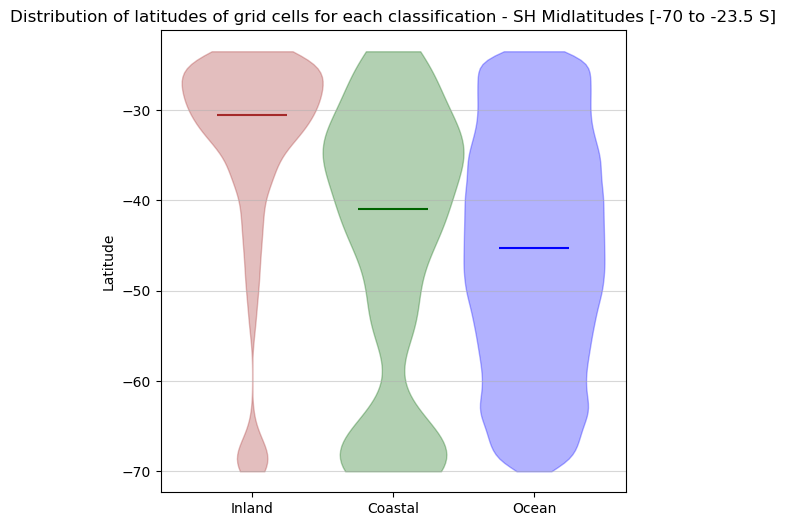

In [13]:
data = [land_lats, coast_lats, ocean_lats]
colors = ['brown', 'darkgreen', 'blue']
labels = ['Inland', 'Coastal', 'Ocean']

fig, ax = plt.subplots(1, 1, figsize=(6,6))
plots = ax.violinplot(data, vert=True, showmedians=True, showextrema=False, widths=1)
for i, (pc,color) in enumerate(zip(plots['bodies'], colors)):
        pc.set_facecolor(color)
        pc.set_edgecolor(color)

# Set the color of the median lines
plots['cmedians'].set_colors(colors)

ax.set_ylabel("Latitude")
ax.set_xticks(np.arange(1,len(labels)+1),labels=labels)
#ax.set_xticks(np.arange(140,300,10))
plt.grid(axis="y", which='both', alpha=0.5)
plt.title("Distribution of latitudes of grid cells for each classification - SH Midlatitudes [-70 to -23.5 S]")
plt.show()

## Plots in SH latitude chunks

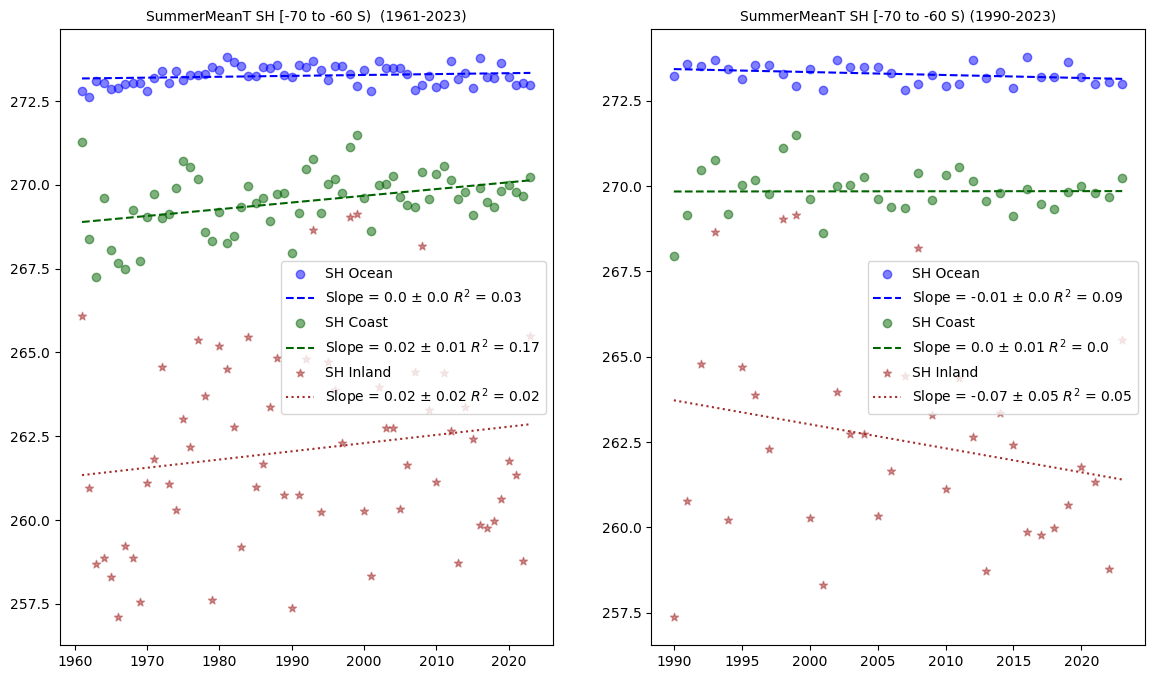

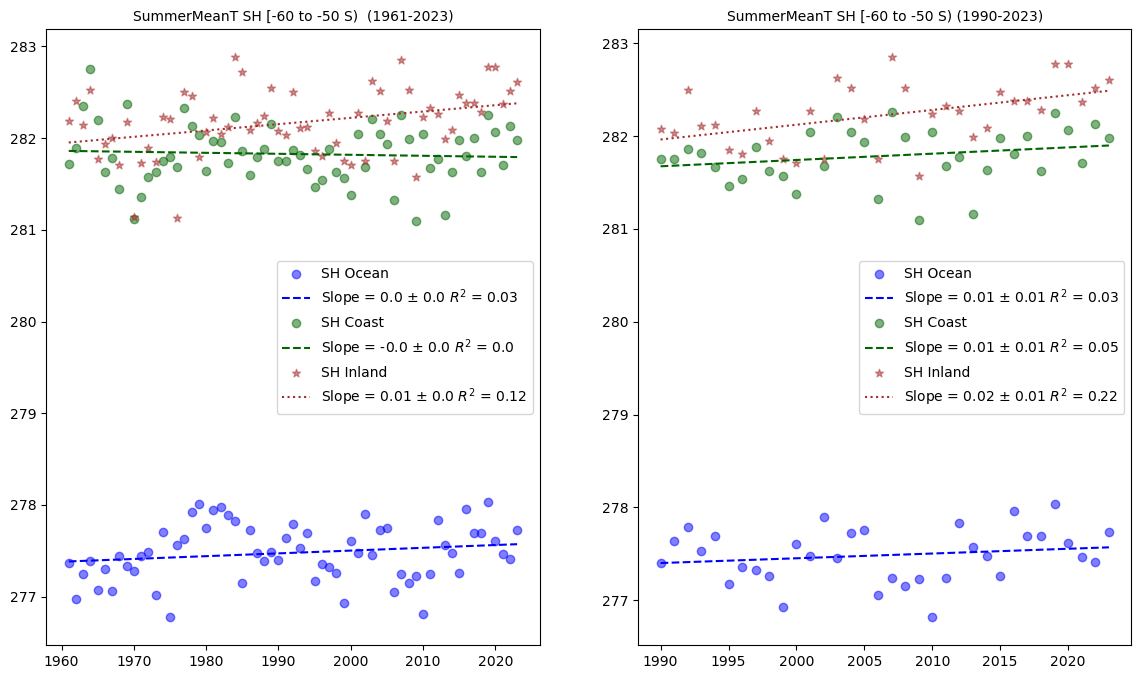

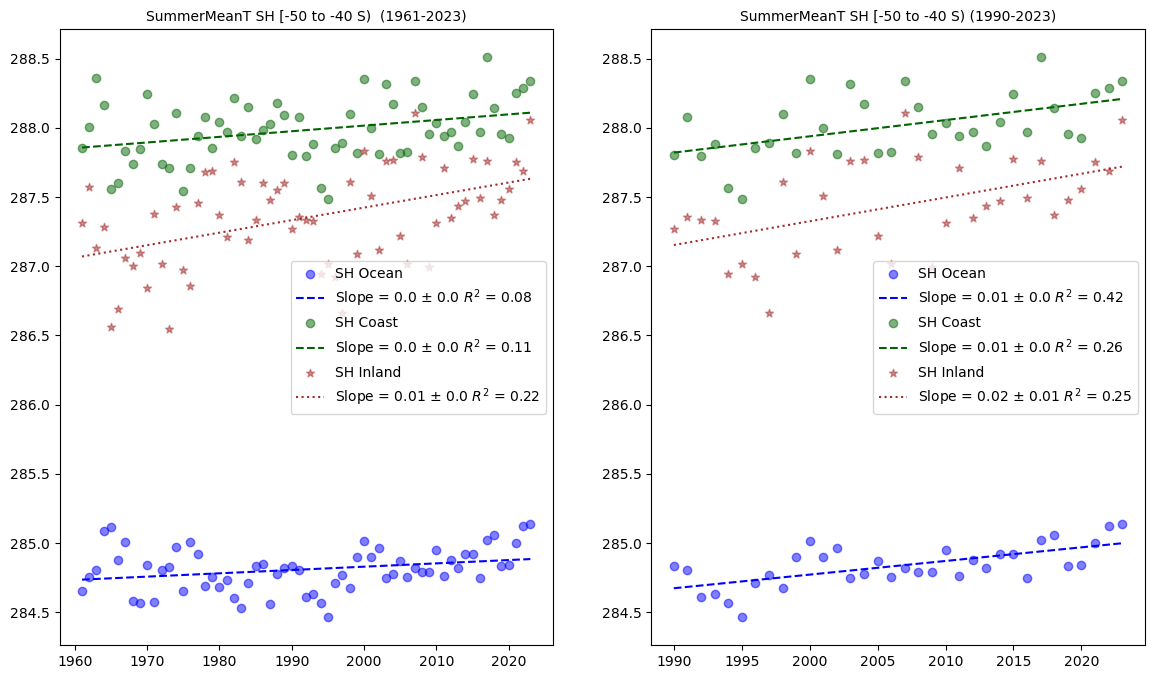

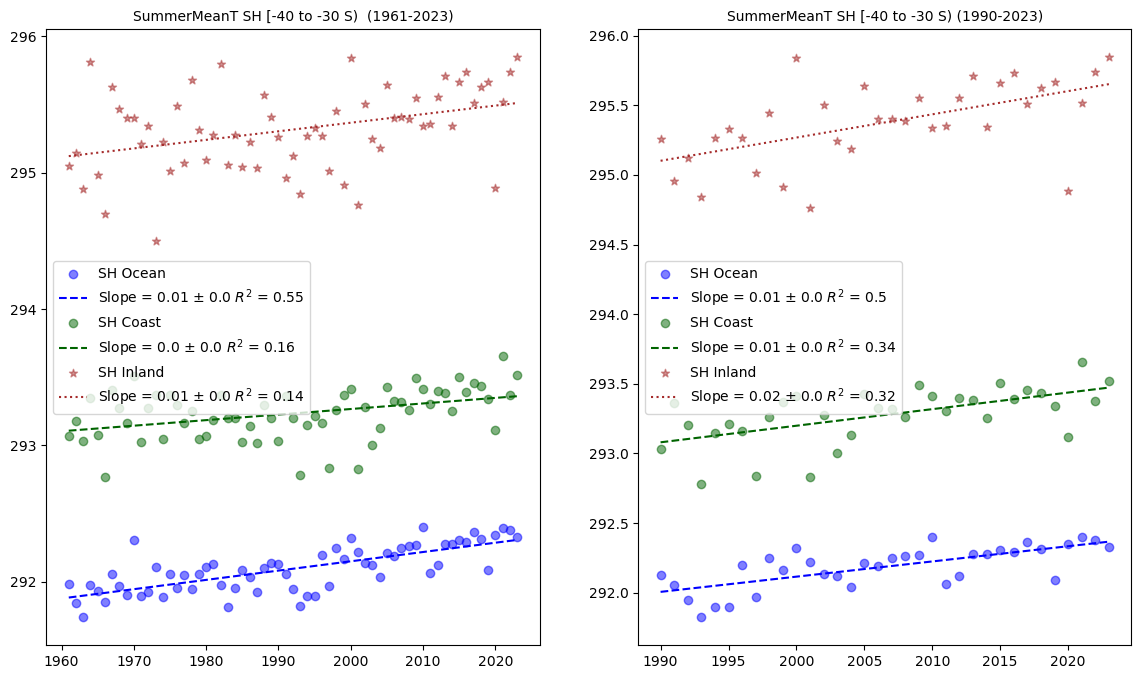

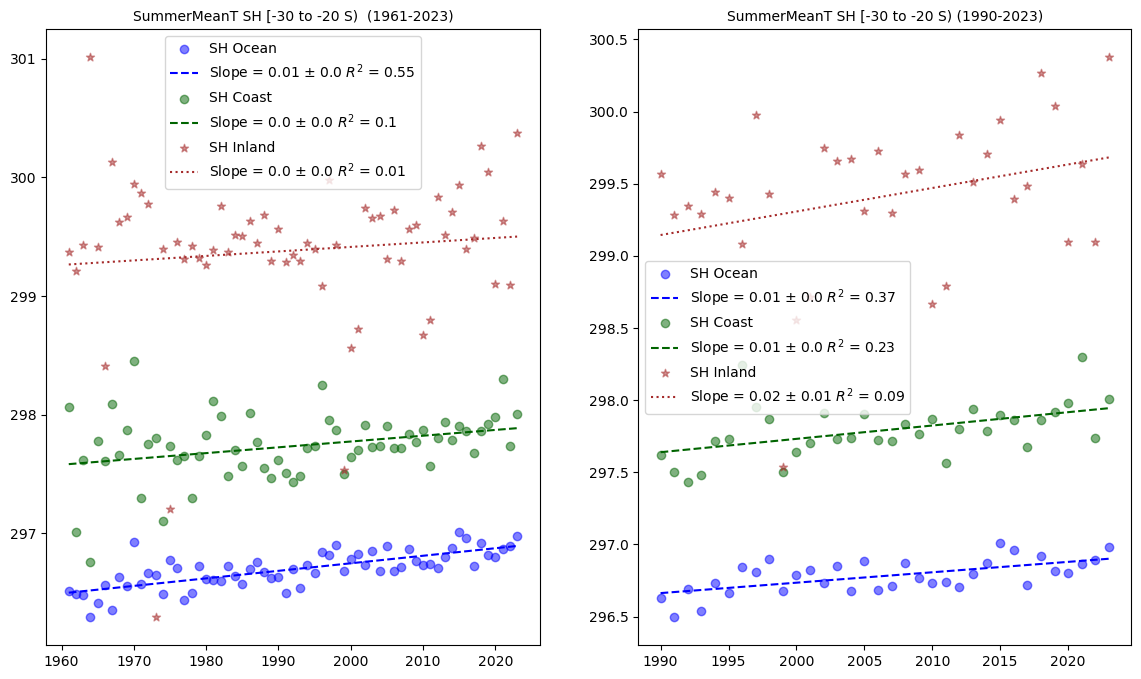

CPU times: user 1min 1s, sys: 34.6 s, total: 1min 35s
Wall time: 1min 37s


In [14]:
%%time

# takes 2 min


# 10 degree latitude buckets
lat_bins = [-70,-60,-50,-40,-30]



# loop through all plot variables
for i,v in enumerate(lat_bins):

    # datasets of weighted averages for the midlatitudes for these lat buckets
    # for now, removing grid cells from averages where the mean summer temp was 0 K meaning no summer
    sh_land_full = ds_full.where((ds_full.lsm > 0.5) & (ds_full.SummerMeanT > 0) & (ds_full.Coastal == False) &
                                 ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
    
    sh_coast_full = ds_full.where((ds_full.Coastal) & (ds_full.SummerMeanT > 0) &
                                  ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    sh_ocean_full = ds_full.where((ds_full.lsm <= 0.5) & (ds_full.SummerMeanT > 0) &
                              ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    sh_ocean_an = ds_full.sel(time=slice('1990','2023')).where((ds_full.lsm <= 0.5) & (ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])
        
    sh_land_an = ds_full.sel(time=slice('1990','2023')).where((ds_full.lsm > 0.5) & (ds_full.SummerMeanT > 0) & (ds_full.Coastal == False) &
                                                          ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])

    sh_coast_an = ds_full.sel(time=slice('1990','2023')).where((ds_full.Coastal) & (ds_full.SummerMeanT > 0) &
                                                           ((ds_full.lat >= v) & (ds_full.lat < (v+10)))).weighted(weights).mean(dim=['lat','lon'])


    
    # create blank fig
    fig = plt.figure(figsize = (14,8))
    
    # Full Time Period NH
    ax1 = fig.add_subplot(1,2,1)

    # linear fits for slope
    x_land = sh_land_full.time.dt.year.values
    y_land = sh_land_full.SummerMeanT.values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_coast = sh_coast_full.time.dt.year.values
    y_coast = sh_coast_full.SummerMeanT.values
    coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
    poly_coast = np.poly1d(coefs_coast)
    slope_coast = np.round(coefs_coast[0],2)
    slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_coast)
    ss_total = np.sum((y_coast - ymean)**2)
    ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_coast = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = sh_ocean_full.time.dt.year.values
    y_ocean = sh_ocean_full.SummerMeanT.values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax1.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", alpha=0.5)
    ax1.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
    ax1.scatter(x_coast, y_coast, label="SH Coast", c="darkgreen", alpha=0.5)
    ax1.plot(x_coast, poly_coast(x_coast), linestyle="dashed", color='darkgreen', 
         label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
    ax1.scatter(x_land, y_land, label="SH Inland", marker='*', facecolors='brown', edgecolors='brown', alpha=0.5)
    ax1.plot(x_land, poly_land(x_land), linestyle="dotted", color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax1.set_title("SummerMeanT SH [" + str(v) +" to " + str(v+10) + " S)  (1961-2023)", fontsize = 10)
    ax1.legend(loc='best')



    # Analysis time period NH
    ax2 = fig.add_subplot(1,2,2)

    # linear fits for slope
    x_land = sh_land_an.time.dt.year.values
    y_land = sh_land_an.SummerMeanT.values
    coefs_land, V = np.polyfit(x_land, y_land, 1, cov=True)
    poly_land = np.poly1d(coefs_land)
    slope_land = np.round(coefs_land[0],2)
    slope_land_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_land)
    ss_total = np.sum((y_land - ymean)**2)
    ss_res = np.sum((y_land - poly_land(x_land))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_land = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_coast = sh_coast_an.time.dt.year.values
    y_coast = sh_coast_an.SummerMeanT.values
    coefs_coast, V = np.polyfit(x_coast, y_coast, 1, cov=True)
    poly_coast = np.poly1d(coefs_coast)
    slope_coast = np.round(coefs_coast[0],2)
    slope_coast_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_coast)
    ss_total = np.sum((y_coast - ymean)**2)
    ss_res = np.sum((y_coast - poly_coast(x_coast))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_coast = np.round(1 - (ss_res / ss_total),2)

    # linear fits for slope
    x_ocean = sh_ocean_an.time.dt.year.values
    y_ocean = sh_ocean_an.SummerMeanT.values
    coefs_ocean, V = np.polyfit(x_ocean, y_ocean, 1, cov=True)
    poly_ocean = np.poly1d(coefs_ocean)
    slope_ocean = np.round(coefs_ocean[0],2)
    slope_ocean_sd = np.round(np.sqrt(V[0][0]),2)  
    # add in R^2 and RMSE
    ymean = np.mean(y_ocean)
    ss_total = np.sum((y_ocean - ymean)**2)
    ss_res = np.sum((y_ocean - poly_ocean(x_ocean))**2)
    #rmse = np.sqrt(ss_res/365.0)
    r_squared_ocean = np.round(1 - (ss_res / ss_total),2)
    
    # plot data
    ax2.scatter(x_ocean, y_ocean, label="SH Ocean", c="blue", alpha=0.5)
    ax2.plot(x_ocean, poly_ocean(x_ocean), linestyle="dashed", color='blue', 
         label="Slope = "+str(slope_ocean)+" $\pm$ "+str(slope_ocean_sd)+" $R^2$ = "+str(r_squared_ocean))
    ax2.scatter(x_coast, y_coast, label="SH Coast", c="darkgreen", alpha=0.5)
    ax2.plot(x_coast, poly_coast(x_coast), linestyle="dashed", color='darkgreen', 
         label="Slope = "+str(slope_coast)+" $\pm$ "+str(slope_coast_sd)+" $R^2$ = "+str(r_squared_coast))
    ax2.scatter(x_land, y_land, label="SH Inland", marker='*', facecolors='brown', edgecolors='brown', alpha=0.5)
    ax2.plot(x_land, poly_land(x_land), linestyle="dotted", color='brown',
         label="Slope = "+str(slope_land)+" $\pm$ "+str(slope_land_sd)+" $R^2$ = "+str(r_squared_land))
    ax2.set_title("SummerMeanT SH [" + str(v) +" to " + str(v+10) + " S) (1990-2023)", fontsize = 10)
    ax2.legend(loc='best')


#plt.tight_layout()
plt.show()

In [15]:
# help from https://www.geeksforgeeks.org/box-plot-in-python-using-matplotlib/#

# data = [land_lats, coast_lats, ocean_lats]

# fig = plt.figure(figsize=(12,6))
# ax = fig.add_subplot(111)

# # Creating axes instance
# bp = ax.boxplot(data, patch_artist = True,
#                 notch ='True',)

# colors = ['brown', 'darkgreen', 'blue']
# labels = ['Inland', 'Coastal', 'Ocean']

# for patch, color in zip(bp['boxes'], colors):
#     patch.set_facecolor(color)

# # x-axis labels
# ax.set_xticklabels(labels)

# ax.set_ylabel("Latitude")

# # Adding title 
# plt.title("Distribution of latitudes of grid cells for each classification - NH Midlatitudes [23.5 - 70 N]")

# Summer Mean T: Determine linear trends per grid cell and write them out

In [16]:
%%time

# limit data to SummerMeanT and only include valid summer mean temp values (0 is equiv to nan)
ds_full_meanT = ds_full.SummerMeanT.where(ds_full.SummerMeanT > 0)

# takes 8.5 min for 63 years

# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = ds_full_meanT.lat.values[:num_lat]
loop_lons = ds_full_meanT.lon.values[:num_lon]


# empty data arrays for summer stats
meanT_slope = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])
meanT_pval = xr.DataArray(np.zeros((num_lat,num_lon)), 
                           coords=[loop_lats, loop_lons], 
                           dims=['lat','lon'])
meanT_r2 = xr.DataArray(np.zeros((num_lat,num_lon)), 
                           coords=[loop_lats, loop_lons], 
                           dims=['lat','lon'])

# add attributes
meanT_slope.attrs["long_name"] = "Slope of linear fit of summer meanT over time"
meanT_slope.attrs["units"] = "Days/year"

meanT_pval.attrs["long_name"] = "p-value of linear fit"
meanT_pval.attrs["units"] = "None"

meanT_r2.attrs["long_name"] = "R^2 (coeff of determination) for linear fit"
meanT_r2.attrs["units"] = "None"


# loop through all of the lat,lon of interest
for input_lat in loop_lats:
    for input_lon in loop_lons:

        # create x & y values for linear fit
        x = ds_full_meanT.time.dt.year.values
        y = ds_full_meanT.sel(lat=input_lat, lon=input_lon).values

        # OLS
        x = sm.add_constant(x)
        model = sm.OLS(y, x).fit()
        #print(model.summary())
        
        # load up data arrays with fit values
        meanT_slope.loc[input_lat, input_lon] = model.params[1]

        # deal with few grid cells that return nan for Pvalue and R2 on fit
        if np.isnan(model.pvalues[1]):
            meanT_pval.loc[input_lat, input_lon] = 1
            meanT_r2.loc[input_lat, input_lon] = 0
        else:
            # otherwise fit pvalue and r2 are OK
            meanT_pval.loc[input_lat, input_lon] = model.pvalues[1]
            meanT_r2.loc[input_lat, input_lon] = model.rsquared
        
# results dataset
results_ds = xr.Dataset(data_vars={'MeanTSlope':meanT_slope,
                           'MeanTPvalue':meanT_pval,
                           'MeanTR2':meanT_r2})

# see results
results_ds

CPU times: user 8min 35s, sys: 2.48 s, total: 8min 37s
Wall time: 8min 37s


<xarray.Dataset> Size: 25MB
Dimensions:      (lat: 721, lon: 1440)
Coordinates:
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    MeanTSlope   (lat, lon) float64 8MB nan nan nan nan nan ... nan nan nan nan
    MeanTPvalue  (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    MeanTR2      (lat, lon) float64 8MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

## Apply FDR

In [17]:
# use func from scipi.stats
pval_fdr_cor = stats.false_discovery_control(results_ds.MeanTPvalue.values)

# add as variable to dataset
results_ds['MeanTPvalFDR'] = (['lat','lon'], pval_fdr_cor)

results_ds

<xarray.Dataset> Size: 33MB
Dimensions:       (lat: 721, lon: 1440)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    MeanTSlope    (lat, lon) float64 8MB nan nan nan nan nan ... nan nan nan nan
    MeanTPvalue   (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    MeanTR2       (lat, lon) float64 8MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    MeanTPvalFDR  (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0

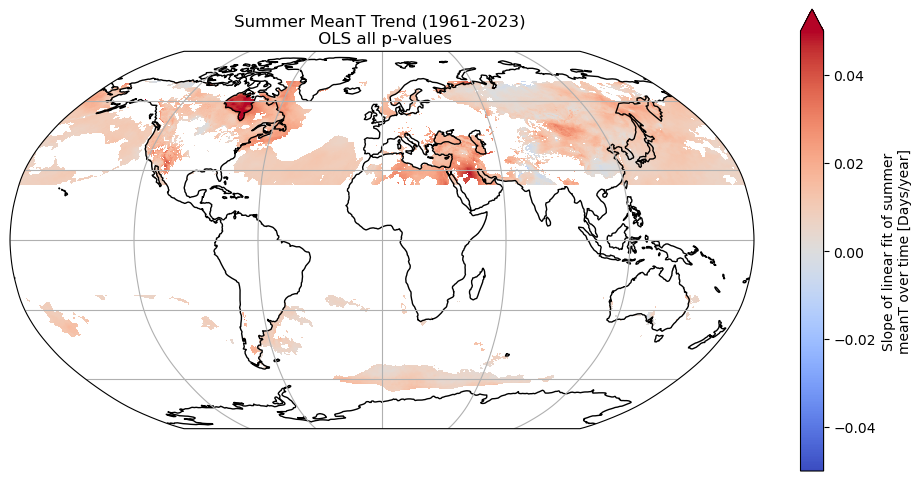

In [23]:

# Global summer MeanT trend
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

results_ds.MeanTSlope.where((((ds_full_meanT.lat >= 23.5) & (ds_full_meanT.lat <= 70)) | 
                              ((ds_full_meanT.lat <= -23.5) & (ds_full_meanT.lat >= -70)))).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-0.05,
    vmax=0.05,
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Summer MeanT Trend (1961-2023) \n OLS all p-values")#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

## Plot using FDR correction on p-values, now with a threshold of 0.1


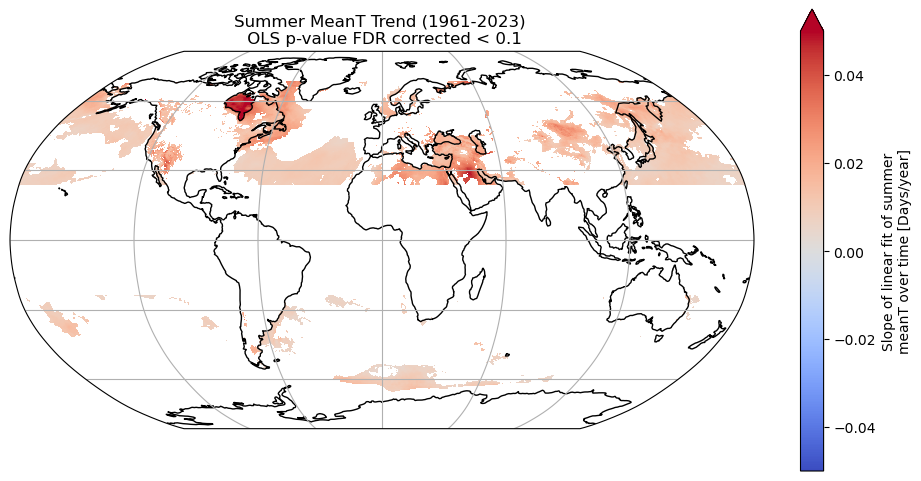

In [22]:

# Global summer MeanT trend
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

results_ds.MeanTSlope.where((results_ds.MeanTPvalFDR <= 0.1) & (((ds_full_meanT.lat >= 23.5) & (ds_full_meanT.lat <= 70)) | 
                              ((ds_full_meanT.lat <= -23.5) & (ds_full_meanT.lat >= -70)))).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-0.05,
    vmax=0.05, 
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Summer MeanT Trend (1961-2023) \n OLS p-value FDR corrected < 0.1")#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerMeanHS_global.png")
plt.show()

## Now do same analysis for Summer MeanT trends over analysis period: 1990-2023

In [24]:
# restrict to 1990-2023
ds_meanT_analysis = ds_full_meanT.sel(time=slice('1990','2023'))
ds_meanT_analysis
                                    

<xarray.DataArray 'SummerMeanT' (time: 34, lat: 721, lon: 1440)> Size: 282MB
array([[[245.2890625 , 245.2890625 , 245.2890625 , ..., 245.2890625 ,
         245.2890625 , 245.2890625 ],
        [245.00108337, 245.00276184, 245.00445557, ..., 244.99609375,
         244.99772644, 244.99943542],
        [244.57606506, 244.57939148, 244.5827179 , ..., 244.53746033,
         244.52375793, 244.57275391],
        ...,
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan]],

       [[         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
...
        [272.91201782, 272.91220093, 272.91229248, ..., 272.91174316,
         272.9118042 , 272.91195679],
        [272.96328735, 272.96331787, 272.96331787, ..., 272.96313477,
         272.96316528, 272.96322632],
        [272.94845581, 272.94845581, 272.94845581, ..., 272.94845581,
         272.94845581, 272.94845581]],

       [[         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        [         nan,          nan,          nan, ...,          nan,
                  nan,          nan],
        ...,
        [272.93347168, 272.94500732, 272.94506836, ..., 272.93331909,
         272.93341064, 272.93338013],
        [272.94192505, 272.94195557, 272.9420166 , ..., 272.94180298,
         272.9418335 , 272.9418335 ],
        [272.9201355 , 272.9201355 , 272.9201355 , ..., 272.9201355 ,
         272.9201355 , 272.9201355 ]]])
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time     (time) datetime64[ns] 272B 1990-01-01 1991-01-01 ... 2023-01-01
Attributes:
    long_name:  Mean temperature during the summer period
    units:      Degrees [K]

### Linear trends for each grid cell 1990-2023

In [26]:
%%time

# takes 10 min for 63 years

# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = ds_meanT_analysis.lat.values[:num_lat]
loop_lons = ds_meanT_analysis.lon.values[:num_lon]

# empty data arrays for summer stats
meanT_slope = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])
meanT_pval = xr.DataArray(np.zeros((num_lat,num_lon)), 
                           coords=[loop_lats, loop_lons], 
                           dims=['lat','lon'])
meanT_r2 = xr.DataArray(np.zeros((num_lat,num_lon)), 
                           coords=[loop_lats, loop_lons], 
                           dims=['lat','lon'])

# add attributes
meanT_slope.attrs["long_name"] = "Slope of linear fit of summer meanT over time"
meanT_slope.attrs["units"] = "Days/year"

meanT_pval.attrs["long_name"] = "p-value of linear fit"
meanT_pval.attrs["units"] = "None"

meanT_r2.attrs["long_name"] = "R^2 (coeff of determination) for linear fit"
meanT_r2.attrs["units"] = "None"


# loop through all of the lat,lon of interest
for input_lat in loop_lats:
    for input_lon in loop_lons:

        # create x & y values for linear fit
        x = ds_meanT_analysis.time.dt.year.values
        y = ds_meanT_analysis.sel(lat=input_lat, lon=input_lon).values

        # OLS
        x = sm.add_constant(x)
        model = sm.OLS(y, x).fit()
        #print(model.summary())
        
        # load up data arrays with fit values
        meanT_slope.loc[input_lat, input_lon] = model.params[1]

        # deal with few grid cells that return nan for Pvalue and R2 on fit
        if (np.isnan(model.pvalues[1]) | np.isnan(model.rsquared)):
            #print("This one has nans: "+str(input_lat)+","+str(input_lon))
            meanT_pval.loc[input_lat, input_lon] = 1.0
            meanT_r2.loc[input_lat, input_lon] = 0.0
        else:
            # otherwise fit pvalue and r2 are OK
            meanT_pval.loc[input_lat, input_lon] = model.pvalues[1]
            meanT_r2.loc[input_lat, input_lon] = model.rsquared
        
# results dataset
results_ds_an = xr.Dataset(data_vars={'MeanTSlope':meanT_slope,
                           'MeanTPvalue':meanT_pval,
                           'MeanTR2':meanT_r2})

# see results
results_ds_an

CPU times: user 9min 2s, sys: 6.05 s, total: 9min 8s
Wall time: 9min 8s


<xarray.Dataset> Size: 25MB
Dimensions:      (lat: 721, lon: 1440)
Coordinates:
  * lat          (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon          (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    MeanTSlope   (lat, lon) float64 8MB nan nan nan nan nan ... nan nan nan nan
    MeanTPvalue  (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    MeanTR2      (lat, lon) float64 8MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [27]:
# diagnose scalar divide warning on some cells - this should be zero so we can do FDR correction
np.count_nonzero(np.isnan(results_ds_an.MeanTPvalue.values))

0

### Apply FDR correction to p-values

In [28]:
# use func from scipi.stats
pval_fdr_cor = stats.false_discovery_control(results_ds_an.MeanTPvalue.values)

# add as variable to dataset
results_ds_an['MeanTPvalFDR'] = (['lat','lon'], pval_fdr_cor)

results_ds_an

<xarray.Dataset> Size: 33MB
Dimensions:       (lat: 721, lon: 1440)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    MeanTSlope    (lat, lon) float64 8MB nan nan nan nan nan ... nan nan nan nan
    MeanTPvalue   (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    MeanTR2       (lat, lon) float64 8MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    MeanTPvalFDR  (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0

In [30]:
# write those results out for later use
output_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_MeanTTrends.nc'
results_ds.to_netcdf(output_path)

output_path2 = '../../../Data/ERA5-global/Analysis/New/1990-2023_MeanTTrends.nc'
results_ds_an.to_netcdf(output_path2)

## also need to do it for Summer Mean HS Days (HSD)

# Summer Mean HSD: Determine linear trends per grid cell and write them out

In [44]:
# limit data to SummerMeanHS and only include valid summer mean temp values (0 is equiv to nan)
ds_full['SummerHSD'] = ds_full.SummerHeat.where(ds_full.SummerMeanT > 0) / ds_full.SummerMeanHS.where(ds_full.SummerMeanT > 0)
ds_full.SummerHSD

<xarray.DataArray 'SummerHSD' (time: 63, lat: 721, lon: 1440)> Size: 523MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [32., 32., 32., ..., 32., 32., 32.],
        [32., 32., 32., ..., 32., 32., 32.],
        [33., 33., 33., ..., 33., 33., 33.]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [35., 35., 35., ..., 35., 35., 35.],
        [31., 31., 31., ..., 31., 31., 31.],
        [30., 30., 30., ..., 30., 30., 30.]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [34., 35., 35., ..., 34., 34., 34.],
        [31., 31., 31., ..., 31., 31., 31.],
        [32., 32., 32., ..., 32., 32., 32.]]])
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time     (time) datetime64[ns] 504B 1961-01-01 1962-01-01 ... 2023-01-01

In [45]:
%%time



# takes 8.5 min for 63 years

# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = ds_full.SummerHSD.lat.values[:num_lat]
loop_lons = ds_full.SummerHSD.lon.values[:num_lon]


# empty data arrays for summer stats
HSD_slope = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])
HSD_pval = xr.DataArray(np.zeros((num_lat,num_lon)), 
                           coords=[loop_lats, loop_lons], 
                           dims=['lat','lon'])
HSD_r2 = xr.DataArray(np.zeros((num_lat,num_lon)), 
                           coords=[loop_lats, loop_lons], 
                           dims=['lat','lon'])

# add attributes
HSD_slope.attrs["long_name"] = "Slope of linear fit of summer HSD over time"
HSD_slope.attrs["units"] = "Days/year"

HSD_pval.attrs["long_name"] = "p-value of linear fit"
HSD_pval.attrs["units"] = "None"

HSD_r2.attrs["long_name"] = "R^2 (coeff of determination) for linear fit"
HSD_r2.attrs["units"] = "None"


# loop through all of the lat,lon of interest
for input_lat in loop_lats:
    for input_lon in loop_lons:

        # create x & y values for linear fit
        x = ds_full.SummerHSD.time.dt.year.values
        y = ds_full.SummerHSD.sel(lat=input_lat, lon=input_lon).values

        # OLS
        x = sm.add_constant(x)
        model = sm.OLS(y, x).fit()
        #print(model.summary())
        
        # load up data arrays with fit values
        HSD_slope.loc[input_lat, input_lon] = model.params[1]

        # deal with few grid cells that return nan for Pvalue and R2 on fit
        if np.isnan(model.pvalues[1]):
            HSD_pval.loc[input_lat, input_lon] = 1
            HSD_r2.loc[input_lat, input_lon] = 0
        else:
            # otherwise fit pvalue and r2 are OK
            HSD_pval.loc[input_lat, input_lon] = model.pvalues[1]
            HSD_r2.loc[input_lat, input_lon] = model.rsquared
        
# results dataset
results_ds = xr.Dataset(data_vars={'HSDSlope':HSD_slope,
                           'HSDPvalue':HSD_pval,
                           'HSDR2':HSD_r2})

# see results
results_ds

CPU times: user 8min 54s, sys: 6.74 s, total: 9min 1s
Wall time: 9min 2s


<xarray.Dataset> Size: 25MB
Dimensions:    (lat: 721, lon: 1440)
Coordinates:
  * lat        (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon        (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    HSDSlope   (lat, lon) float64 8MB nan nan nan nan nan ... nan nan nan nan
    HSDPvalue  (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    HSDR2      (lat, lon) float64 8MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

## Apply FDR

In [46]:
# use func from scipi.stats
pval_fdr_cor = stats.false_discovery_control(results_ds.HSDPvalue.values)

# add as variable to dataset
results_ds['HSDPvalFDR'] = (['lat','lon'], pval_fdr_cor)

results_ds

<xarray.Dataset> Size: 33MB
Dimensions:     (lat: 721, lon: 1440)
Coordinates:
  * lat         (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon         (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    HSDSlope    (lat, lon) float64 8MB nan nan nan nan nan ... nan nan nan nan
    HSDPvalue   (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    HSDR2       (lat, lon) float64 8MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    HSDPvalFDR  (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0

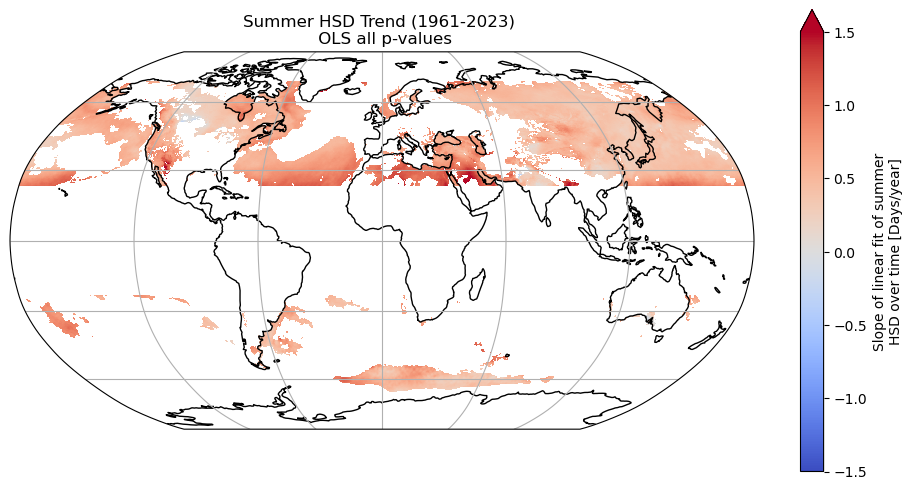

In [48]:

# Global summer HSD trend
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

results_ds.HSDSlope.where((((ds_full.SummerHSD.lat >= 23.5) & (ds_full.SummerHSD.lat <= 70)) | 
                              ((ds_full.SummerHSD.lat <= -23.5) & (ds_full.SummerHSD.lat >= -70)))).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-1.5,
    vmax=1.5,
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Summer HSD Trend (1961-2023) \n OLS all p-values")#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerHSD_global.png")
plt.show()

## Plot using FDR correction on p-values, now with a threshold of 0.1


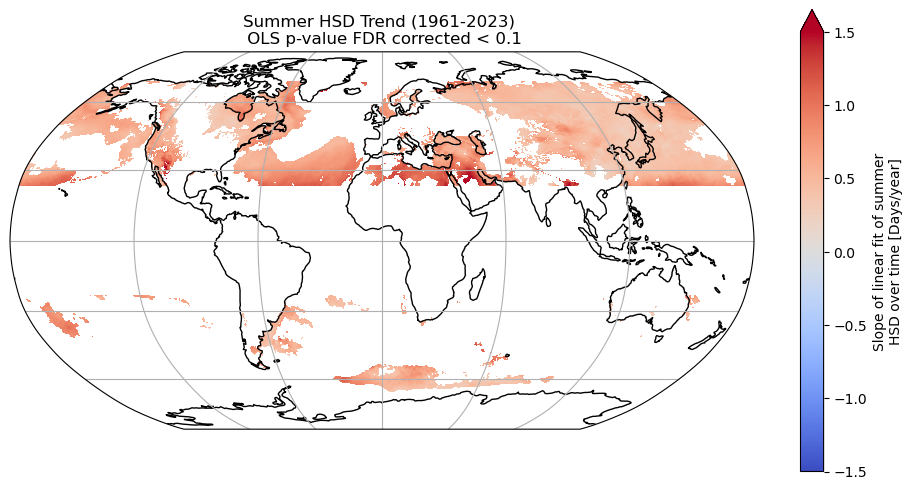

In [49]:

# Global summer HSD trend
fig = plt.figure(figsize=(12,6))

# assign axis and def projection to use
ax = plt.axes(projection=ccrs.Robinson(central_longitude=0))

# add coastlines and grid
ax.coastlines()
ax.gridlines()

results_ds.HSDSlope.where((results_ds.HSDPvalFDR <= 0.1) & (((ds_full.SummerHSD.lat >= 23.5) & (ds_full.SummerHSD.lat <= 70)) | 
                              ((ds_full.SummerHSD.lat <= -23.5) & (ds_full.SummerHSD.lat >= -70)))).plot(
    ax=ax,
    transform=ccrs.PlateCarree(), # assign map projection
    vmin=-1.5,
    vmax=1.5, 
    cmap="coolwarm"#"YlOrRd"#cmap="coolwarm"
)

plt.title("Summer HSD Trend (1961-2023) \n OLS p-value FDR corrected < 0.1")#+" using 1961-1990 baseline")
#plt.savefig("./Plots/"+str(input_year)+"_SummerHSD_global.png")
plt.show()

## Now do same analysis for Summer HSD trends over analysis period: 1990-2023

In [50]:
# restrict to 1990-2023
ds_HSD_analysis = ds_full.SummerHSD.sel(time=slice('1990','2023'))
ds_HSD_analysis
                                    

<xarray.DataArray 'SummerHSD' (time: 34, lat: 721, lon: 1440)> Size: 282MB
array([[[75., 75., 75., ..., 75., 75., 75.],
        [72., 72., 72., ..., 72., 72., 72.],
        [71., 71., 71., ..., 73., 72., 71.],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [35., 35., 35., ..., 35., 35., 35.],
        [31., 31., 31., ..., 31., 31., 31.],
        [29., 29., 29., ..., 29., 29., 29.]],

       [[61., 61., 61., ..., 61., 61., 61.],
        [58., 58., 58., ..., 57., 57., 57.],
        [53., 53., 52., ..., 53., 53., 53.],
        ...,
...
        ...,
        [32., 32., 32., ..., 32., 32., 32.],
        [32., 32., 32., ..., 32., 32., 32.],
        [33., 33., 33., ..., 33., 33., 33.]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [35., 35., 35., ..., 35., 35., 35.],
        [31., 31., 31., ..., 31., 31., 31.],
        [30., 30., 30., ..., 30., 30., 30.]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [34., 35., 35., ..., 34., 34., 34.],
        [31., 31., 31., ..., 31., 31., 31.],
        [32., 32., 32., ..., 32., 32., 32.]]])
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.5 89.75 90.0
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
  * time     (time) datetime64[ns] 272B 1990-01-01 1991-01-01 ... 2023-01-01

### Linear trends for each grid cell 1990-2023

In [37]:
%%time

# takes 10 min for 63 years

# grid parameters for looping
num_lat = 721
num_lon = 1440

loop_lats = ds_HSD_analysis.lat.values[:num_lat]
loop_lons = ds_HSD_analysis.lon.values[:num_lon]

# empty data arrays for summer stats
HSD_slope = xr.DataArray(np.zeros((num_lat,num_lon)), 
                            coords=[loop_lats, loop_lons], 
                            dims=['lat','lon'])
HSD_pval = xr.DataArray(np.zeros((num_lat,num_lon)), 
                           coords=[loop_lats, loop_lons], 
                           dims=['lat','lon'])
HSD_r2 = xr.DataArray(np.zeros((num_lat,num_lon)), 
                           coords=[loop_lats, loop_lons], 
                           dims=['lat','lon'])

# add attributes
HSD_slope.attrs["long_name"] = "Slope of linear fit of summer HSD over time"
HSD_slope.attrs["units"] = "Days/year"

HSD_pval.attrs["long_name"] = "p-value of linear fit"
HSD_pval.attrs["units"] = "None"

HSD_r2.attrs["long_name"] = "R^2 (coeff of determination) for linear fit"
HSD_r2.attrs["units"] = "None"


# loop through all of the lat,lon of interest
for input_lat in loop_lats:
    for input_lon in loop_lons:

        # create x & y values for linear fit
        x = ds_HSD_analysis.time.dt.year.values
        y = ds_HSD_analysis.sel(lat=input_lat, lon=input_lon).values

        # OLS
        x = sm.add_constant(x)
        model = sm.OLS(y, x).fit()
        #print(model.summary())
        
        # load up data arrays with fit values
        HSD_slope.loc[input_lat, input_lon] = model.params[1]

        # deal with few grid cells that return nan for Pvalue and R2 on fit
        if (np.isnan(model.pvalues[1]) | np.isnan(model.rsquared)):
            #print("This one has nans: "+str(input_lat)+","+str(input_lon))
            HSD_pval.loc[input_lat, input_lon] = 1.0
            HSD_r2.loc[input_lat, input_lon] = 0.0
        else:
            # otherwise fit pvalue and r2 are OK
            HSD_pval.loc[input_lat, input_lon] = model.pvalues[1]
            HSD_r2.loc[input_lat, input_lon] = model.rsquared
        
# results dataset
results_ds_an = xr.Dataset(data_vars={'HSDSlope':HSD_slope,
                           'HSDPvalue':HSD_pval,
                           'HSDR2':HSD_r2})

# see results
results_ds_an

CPU times: user 9min 6s, sys: 8.22 s, total: 9min 14s
Wall time: 9min 15s


<xarray.Dataset> Size: 25MB
Dimensions:       (lat: 721, lon: 1440)
Coordinates:
  * lat           (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon           (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    MeanHSSlope   (lat, lon) float64 8MB nan nan nan nan nan ... nan nan nan nan
    MeanHSPvalue  (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    MeanHSR2      (lat, lon) float64 8MB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

In [38]:
# diagnose scalar divide warning on some cells - this should be zero so we can do FDR correction
np.count_nonzero(np.isnan(results_ds_an.HSDPvalue.values))

0

### Apply FDR correction to p-values

In [39]:
# use func from scipi.stats
pval_fdr_cor = stats.false_discovery_control(results_ds_an.HSDPvalue.values)

# add as variable to dataset
results_ds_an['HSDPvalFDR'] = (['lat','lon'], pval_fdr_cor)

results_ds_an

<xarray.Dataset> Size: 33MB
Dimensions:        (lat: 721, lon: 1440)
Coordinates:
  * lat            (lat) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * lon            (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    MeanHSSlope    (lat, lon) float64 8MB nan nan nan nan ... nan nan nan nan
    MeanHSPvalue   (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0
    MeanHSR2       (lat, lon) float64 8MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    MeanHSPvalFDR  (lat, lon) float64 8MB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0

In [40]:
# write those results out for later use
output_path = '../../../Data/ERA5-global/Analysis/New/1961-2023_HSDTrends.nc'
results_ds.to_netcdf(output_path)

output_path2 = '../../../Data/ERA5-global/Analysis/New/1990-2023_HSDTrends.nc'
results_ds_an.to_netcdf(output_path2)